In [ ]:
#Setting project folder
from google.colab import drive

drive.mount('/content/drive')

import os

os.chdir(
"/content/drive/MyDrive/Uber_Demand_Forecasting_Project"
)

Mounted at /content/drive


In [ ]:
#Import libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt


In [ ]:
#Load dataset
data = pd.read_csv("uber_data.csv")

data['Date/Time'] = pd.to_datetime(
    data['Date/Time']
)

data.head()

,Date/Time,Lat,Lon,Base
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512


In [ ]:
#Convert raw rides into hourly demand
hourly_data = (
    data
    .set_index('Date/Time')
    .resample('H')
    .size()
)


hourly_data = hourly_data.to_frame(
    name="Trips"
)


hourly_data.head()

/tmp/ipykernel_2498/2645609535.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('H')


,Trips
Date/Time,
2014-04-01 00:00:00,138
2014-04-01 01:00:00,66
2014-04-01 02:00:00,53
2014-04-01 03:00:00,93
2014-04-01 04:00:00,166


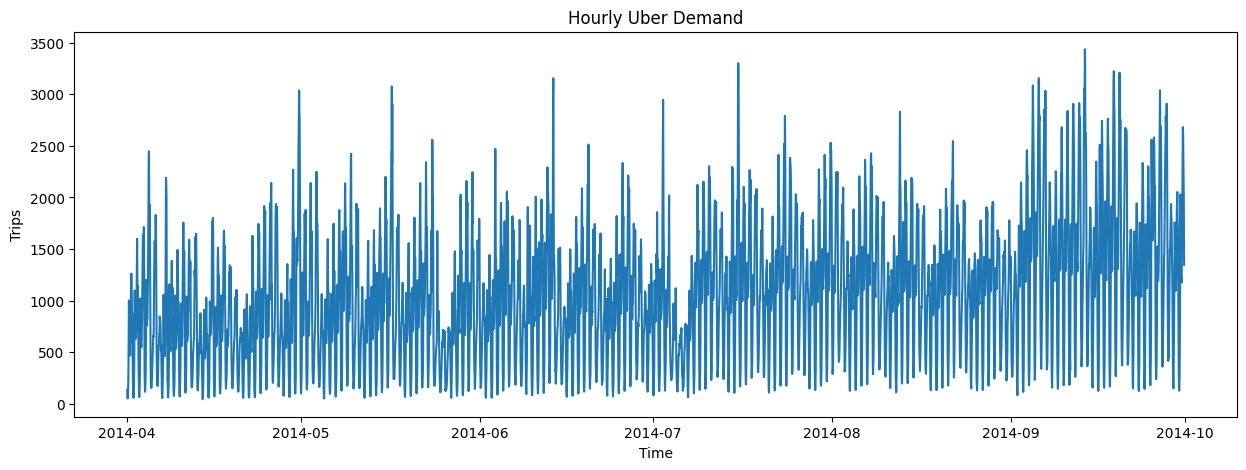

In [ ]:
#Visualize time series
plt.figure(figsize=(15,5))

plt.plot(
    hourly_data['Trips']
)

plt.title(
    "Hourly Uber Demand"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Trips"
)

plt.show()

In [ ]:
#Normaize data
scaler = MinMaxScaler()


scaled_data = scaler.fit_transform(
    hourly_data
)

In [ ]:
#Create sequences
def create_sequences(data, seq_length=168):

    X = []
    y = []

    for i in range(len(data)-seq_length):

        X.append(
            data[i:i+seq_length]
        )

        y.append(
            data[i+seq_length]
        )

    return np.array(X), np.array(y)

X, y = create_sequences(
    scaled_data,
    168
)


print(X.shape)
print(y.shape)

(4223, 168, 1)
(4223, 1)


In [ ]:
#Train-Test split
split = int(
    len(X)*0.8
)


X_train = X[:split]

X_test = X[split:]


y_train = y[:split]

y_test = y[split:]

In [ ]:
#Build LSTM model
model = Sequential([


    LSTM(
        128,
        return_sequences=True,
        input_shape=(168,1)
    ),


    Dropout(0.2),


    LSTM(
        64
    ),


    Dropout(0.2),


    Dense(
        32,
        activation='relu'
    ),


    Dense(
        1
    )

])


model.compile(
    optimizer='adam',
    loss='mse'
)


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history = model.fit(

    X_train,
    y_train,

    epochs=30,

    batch_size=64,

    validation_data=(
        X_test,
        y_test
    ),

    callbacks=[
        early_stop
    ]
)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 593ms/step - loss: 0.0269 - val_loss: 0.0247
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 501ms/step - loss: 0.0105 - val_loss: 0.0138
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 468ms/step - loss: 0.0080 - val_loss: 0.0114
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 532ms/step - loss: 0.0073 - val_loss: 0.0098
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 515ms/step - loss: 0.0063 - val_loss: 0.0100
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 518ms/step - loss: 0.0062 - val_loss: 0.0075
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 43s 553ms/step - loss: 0.0055 - val_loss: 0.0082
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 510ms/step - loss: 0.0052 - val_loss: 0.0073
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 471ms/step - loss: 0.0049 - val_loss: 0.0061
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 472ms/step - loss: 0.0046 - val_loss: 0.0061
Epoch 11/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 506ms/step - loss: 0.0041 - val_loss: 0.0051
Epoch 12/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 27

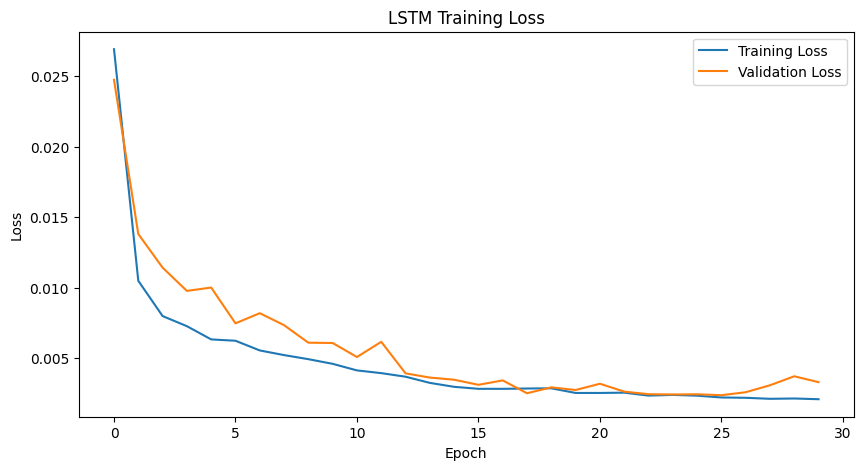

In [ ]:
#Plot training loss
plt.figure(figsize=(10,5))


plt.plot(
    history.history['loss'],
    label="Training Loss"
)


plt.plot(
    history.history['val_loss'],
    label="Validation Loss"
)


plt.title(
    "LSTM Training Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.legend()

plt.show()

In [ ]:
#Prediction
predictions = model.predict(
    X_test
)

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step


In [ ]:
#Reverse scaling
predictions = scaler.inverse_transform(
    predictions
)


actual = scaler.inverse_transform(
    y_test
)

In [ ]:
#Model evaluation
mae = mean_absolute_error(
    actual,
    predictions
)


rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)


r2 = r2_score(
    actual,
    predictions
)



print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 119.1827132004958
RMSE: 165.07880249736402
R2 Score: 0.9530817819987942


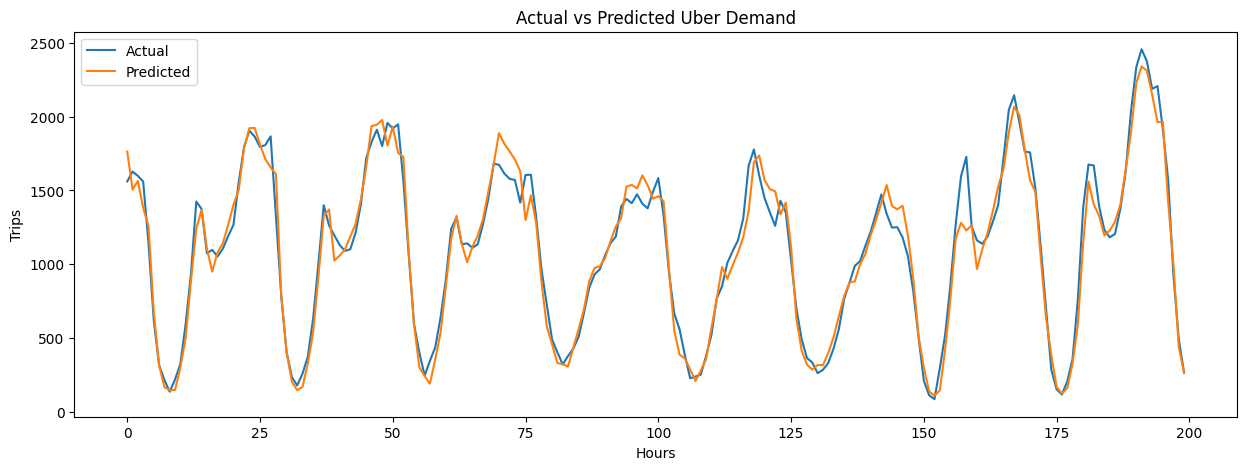

In [ ]:
#Actual VS Predicted graph
plt.figure(figsize=(15,5))


plt.plot(
    actual[:200],
    label="Actual"
)


plt.plot(
    predictions[:200],
    label="Predicted"
)


plt.title(
    "Actual vs Predicted Uber Demand"
)


plt.xlabel(
    "Hours"
)


plt.ylabel(
    "Trips"
)


plt.legend()

plt.show()

In [ ]:
#Save LSTM model
model.save(
    "lstm_model.h5"
)

In [ ]:
#Download model
from google.colab import files

files.download(
    "lstm_model.h5"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>